In [ ]:
# !pip install bertopic

In [2]:
from bertopic import BERTopic

In [3]:
import pandas as pd
import numpy as np
import nltk
import nltk.corpus
import nltk.sentiment
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords

nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('punkt_tab')
import os

import re
import string
from string import punctuation

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score


import gensim
from gensim import corpora

import pyLDAvis
import pyLDAvis.gensim
nltk.download('vader_lexicon')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to

ImportError: cannot import name 'triu' from 'scipy.linalg' (C:\Users\Acer\anaconda3\Lib\site-packages\scipy\linalg\__init__.py)

In [170]:
from transformers import AutoTokenizer
import torch
import numpy as np
import pandas as pd
df = pd.read_csv("reviews_clean_csv_portinari.csv")

In [172]:
df[['title_review_en', 'neg_review_en','pos_review_en']] = df[['title_review_en', 'neg_review_en','pos_review_en']].replace("No review", "")

In [174]:
df['title_review_en'] = df['title_review_en'].fillna('') 
df['neg_review_en'] = df['neg_review_en'].fillna('')  
df['pos_review_en'] = df['pos_review_en'].fillna('') 

# 2. Ensure all values are strings
df['title_review_en'] = df['title_review_en'].astype(str)
df['neg_review_en'] = df['neg_review_en'].astype(str)
df['pos_review_en'] = df['pos_review_en'].astype(str)

In [176]:
df['review'] = df[['title_review_en', 'pos_review_en', 'neg_review_en']].agg(' '.join, axis=1)

In [178]:
df['review'] = df['review'].apply(lambda x: word_tokenize(x.lower()))
#df['review'].str.replace("[","")

In [180]:
# stopwords = stopwords.words('english')
# punctuation = list(punctuation)
# words = set(nltk.corpus.words.words())   
# df['review'] = df['review'].apply(lambda x: [t for t in x if t not in stopwords and t not in punctuation and t in words])

In [182]:
default_stopwords = set(stopwords.words('english'))  
punctuation_set = set(punctuation)  
valid_words = set(nltk.corpus.words.words())  

# 2. Add your custom words (e.g., generic sentiment + hotel-specific terms)
custom_stopwords = ["good", "superb", "poor", "nice", "bad", "great","passable","disappointing","regular","closed","exceptional","pleasant"]
all_stopwords = default_stopwords.union(custom_stopwords)  # Combine sets

# 3. Apply filtering to DataFrame
df['review'] = df['review'].apply(
    lambda x: [t for t in x 
              if t not in all_stopwords 
              and t not in punctuation_set 
              and t in valid_words]
)

In [184]:
df['review']=df['review'].apply(str)

In [186]:
# Initialize BERTopic with custom tokenizer
topic_model = BERTopic(
    language="english",
    embedding_model="bert-base-uncased",
    verbose=True
)

In [164]:
#Customize to extract meaningful phrases
topic_model = BERTopic(
    n_gram_range=(1, 2),       # Include bigrams (e.g., "friendly staff")
    top_n_words=10,             # Show more words per topic
    min_topic_size=10,         # Merge small topics
    nr_topics="Auto"           # Let BERTopic decide optimal topic count
)

In [188]:
# Fit the model
topics, probs = topic_model.fit_transform(df['review'])

2025-04-01 17:30:45,395 - BERTopic - Embedding - Transforming documents to embeddings.
No sentence-transformers model found with name bert-base-uncased. Creating a new one with mean pooling.


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

2025-04-01 17:31:49,354 - BERTopic - Embedding - Completed ✓
2025-04-01 17:31:49,354 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-01 17:31:53,199 - BERTopic - Dimensionality - Completed ✓
2025-04-01 17:31:53,199 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-01 17:31:53,251 - BERTopic - Cluster - Completed ✓
2025-04-01 17:31:53,251 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-01 17:31:53,270 - BERTopic - Representation - Completed ✓


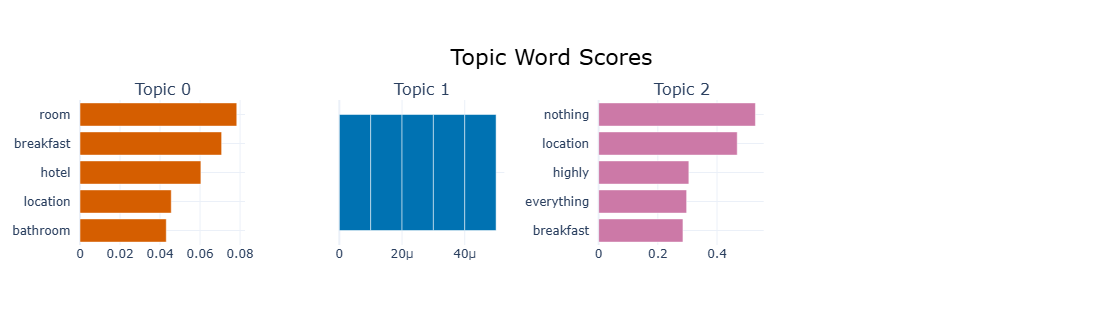

In [190]:
# Visualize topics
topic_model.visualize_barchart()

In [196]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (first time only)
nltk.download('vader_lexicon')

# Initialize analyzer
sid = SentimentIntensityAnalyzer()

# Words to analyze
words = ["room", "breakfast", "hotel", "location", "bathroom"]

# Get sentiment scores
for word in words:
    scores = sid.polarity_scores(word)
    print(f"{word}: {scores['compound']:.2f} (Pos: {scores['pos']:.2f}, Neg: {scores['neg']:.2f})")

room: 0.00 (Pos: 0.00, Neg: 0.00)
breakfast: 0.00 (Pos: 0.00, Neg: 0.00)
hotel: 0.00 (Pos: 0.00, Neg: 0.00)
location: 0.00 (Pos: 0.00, Neg: 0.00)
bathroom: 0.00 (Pos: 0.00, Neg: 0.00)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
